In [1]:
import collections
import matplotlib.pyplot as plt
from IPython import display
import numpy as np
import copy

import torch
from torch import Tensor, nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

from common.model.cnn_simple import CIFAR10ReLU
from common.const import DATASET_PATH
from common.util import *
from common.meta import MetaData
from common.optimise_v4 import NetLineStepProcessor

from torchvision.datasets import CIFAR10
from torchvision import transforms

import logging

In [2]:
logging.basicConfig(filename="log_convcrity_cifar10_epochsd_v3.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s")
#                datefmt="%m/%d/%Y %I:%M:%S")


#### CIFAR10 dataset

In [3]:
# Convert from PIL to torch.Tensort
# and normalize each pixel from [0, 255] range to [0.0, 1.0]
base_transforms = transforms.ToTensor()

# An augmentation that randomly (with a probability equal to 0.5)
# flips the image horizontally
# This will prevent overfitting and make the model more robust
aug_transforms = transforms.RandomHorizontalFlip(p=0.5)

# Gather all transforms together
train_transforms = transforms.Compose([
    base_transforms,
    aug_transforms
])

train_dataset = CIFAR10(root=DATASET_PATH, train=True, download=True, transform=train_transforms)

# Note that we only use `base_transforms` for test dataset
test_dataset = CIFAR10(root=DATASET_PATH, train=False, download=True, transform=base_transforms)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
BATCH_SIZE = 128 #64 #32

# `pin_memory` speed up processing if you use GPU
# `num_workers` also speed up processing since use additional process
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             num_workers=0, pin_memory=True)

In [5]:
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.1
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

INPUT_DIM=32*32 #*3 USING 0.299 ∙ Red + 0.587 ∙ Green + 0.114 ∙ Blue for gray-transform
OUTPUT_DIM = 10 #26  # num of classes

lb, lw = 0.005, 5.0
meta = MetaData(input_dim = INPUT_DIM, output_dim = OUTPUT_DIM, batch_size = BATCH_SIZE, lb = 0.005, lw = 5.0, reduction='mean')

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


##### UTILS

#### Compare optimisers

In [6]:
def print_comparison(HISTORY_NORM2, HISTORY_OPTFIX, HISTORY_ADAM):
    #start_epoch, finish_epoch = 10, 20
    display.clear_output()
    fig, axes = plt.subplots(2, 1, figsize=(12, 16))
    axes[0].set_title('Loss (Cross Entropy)')
    #axes[0].set_xlim(start_epoch-1, finish_epoch)
    #axes[0].plot(HISTORY_NORM1['train_loss'][2:40], color='g', ls='dotted', alpha=.5, label='Train norm1')
    #axes[0].plot(HISTORY_NORM2['train_loss'][2:40], color='b', ls='dotted', alpha=.5, label='Train norm2')
    #axes[0].plot(HISTORY_ZHS['train_loss'][2:40], color='r', ls='dotted', alpha=.5, label='Train Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['train_loss'][2:40], color='orange', ls='dotted', alpha=.5, label='Train Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['train_loss'][2:40], color='brown', ls='dotted', alpha=.5, label='Train direct Zhang-lambda')
    axes[0].plot(HISTORY_ADAM['test_loss'], color='g', alpha=.5, label='Adam')
    axes[0].plot(HISTORY_NORM2['test_loss'], color='b', alpha=.5, label='Net-line')
    #axes[0].plot(HISTORY_ZHS['test_loss'], color='r', alpha=.5, label='Test Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['test_loss'], color='orange', alpha=.5, label='Test Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['test_loss'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[0].plot(HISTORY_OPTFIX['test_loss'], color='grey', alpha=.5, label='SGD')
    axes[0].grid()
    axes[0].legend()
    axes[0].set_xlabel("Epoch (series of gradient descent steps)")
    axes[0].set_ylabel("Loss value")

    axes[1].set_title('Accuracy')
    #axes[1].set_xlim(10, 20)
    #axes[1].plot(HISTORY_NORM1['train_accuracy'][2:40], color='g', alpha=.5, ls='dotted', label='Train norm1')
    #axes[1].plot(HISTORY_NORM2['train_accuracy'][2:40], color='b', alpha=.5, ls='dotted', label='Train norm2')
    #axes[1].plot(HISTORY_ZHS['train_accuracy'][2:40], color='r', alpha=.5, ls='dotted', label='Train Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['train_accuracy'][2:40], color='orange', alpha=.5, ls='dotted', label='Train Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['train_accuracy'][2:40], color='brown', alpha=.5, ls='dotted', label='Train direct Zhang-lambda')
    axes[1].plot(HISTORY_ADAM['test_accuracy'], color='g', alpha=.5, label='Adam')
    axes[1].plot(HISTORY_NORM2['test_accuracy'], color='b', alpha=.5, label='Net-line')
    #axes[1].plot(HISTORY_ZHS['test_accuracy'], color='r', alpha=.5, label='Test Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['test_accuracy'], color='orange', alpha=.5, label='Test Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['test_accuracy'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[1].plot(HISTORY_OPTFIX['test_accuracy'], color='grey', alpha=.5, label='SGD')
    axes[1].grid()
    axes[1].legend()
    axes[1].set_xlabel("Epoch (series of gradient descent steps)")
    axes[1].set_ylabel("Accuracy value")

    #fig.tight_layout()
    #fig.subplots_adjust(top=0.95)
    dummy=fig.suptitle("Comparison for the same CNN architecture for different optimisers")

    plt.show()

#### Reference CNN

In [7]:
def make_model(dropout_const = 1.0):
    
    model = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25*dropout_const),
        nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25*dropout_const),
        nn.Flatten(),
        nn.Linear(4096, 256),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.5*dropout_const),
        nn.Linear(256, 10)
    )

    return model

In [8]:
HISTORY_NORM2 = collections.defaultdict(list)
HISTORY_OPTFIX = collections.defaultdict(list)
HISTORY_ADAM = collections.defaultdict(list)

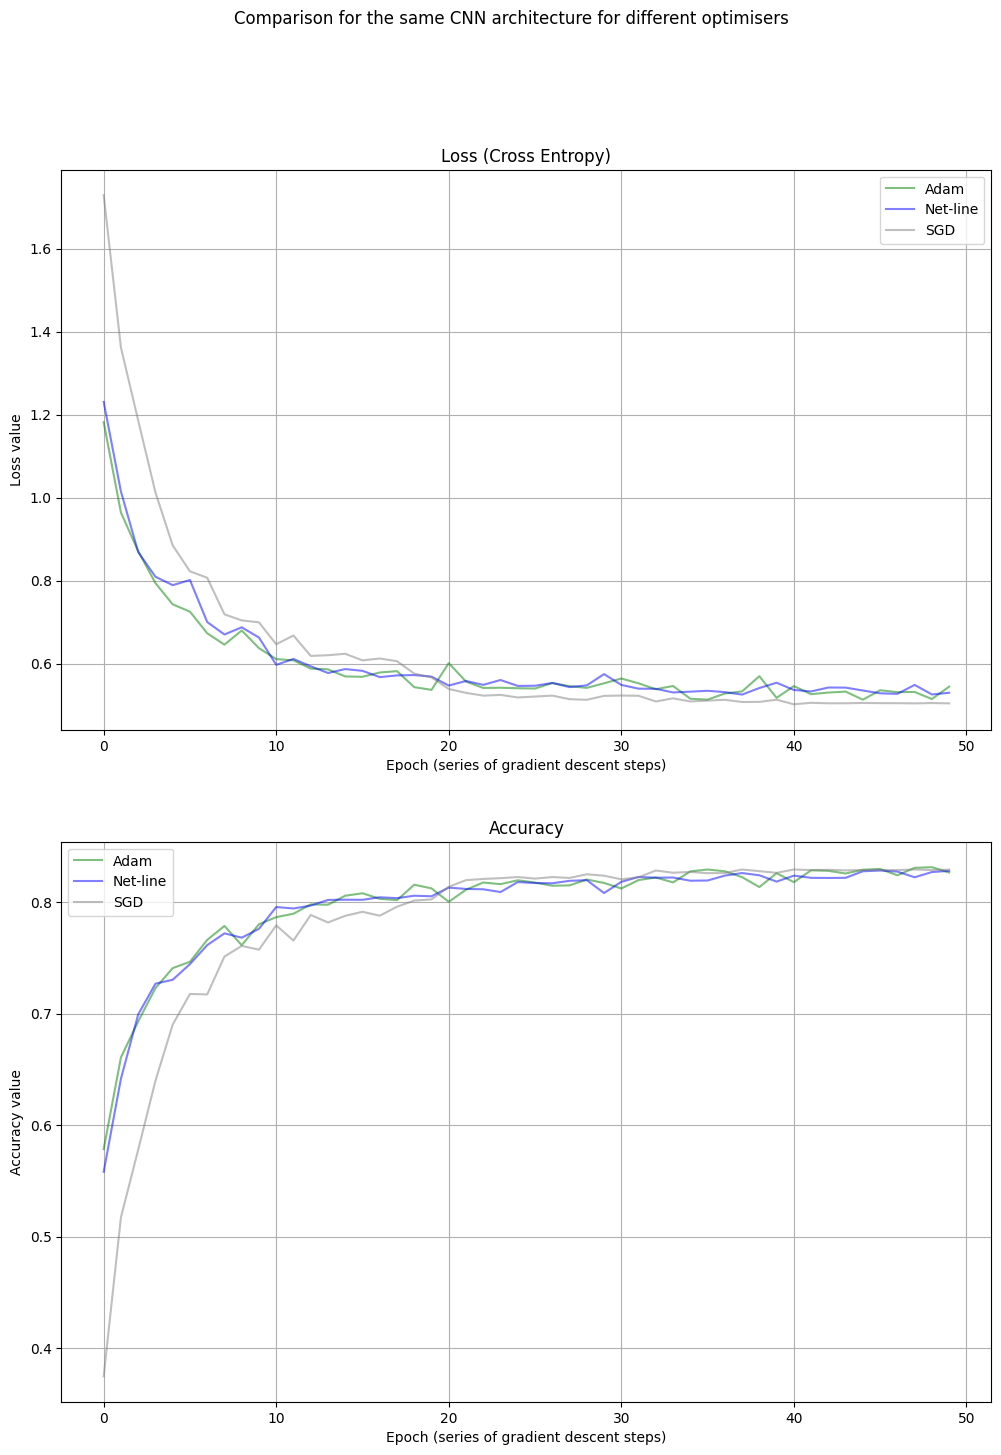

accuracy norm2=[0.5582205414012739, 0.6416202229299363, 0.6992436305732485, 0.7268113057324841, 0.7302945859872612, 0.744327229299363, 0.7613455414012739, 0.7718949044585988, 0.7680135350318471, 0.7759753184713376, 0.7954816878980892, 0.794187898089172, 0.7967754777070064, 0.8018511146496815, 0.8020501592356688, 0.8019506369426752, 0.8042396496815286, 0.8034434713375797, 0.8056329617834395, 0.8051353503184714, 0.8128980891719745, 0.8117038216560509, 0.81140525477707, 0.8089171974522293, 0.8178742038216561, 0.8169785031847133, 0.8167794585987261, 0.818968949044586, 0.8195660828025477, 0.8080214968152867, 0.8180732484076433, 0.822452229299363, 0.8217555732484076, 0.8219546178343949, 0.8190684713375797, 0.8192675159235668, 0.8236464968152867, 0.8259355095541401, 0.8239450636942676, 0.8182722929936306, 0.8236464968152867, 0.821656050955414, 0.8215565286624203, 0.821656050955414, 0.8275278662420382, 0.8282245222929936, 0.8272292993630573, 0.8221536624203821, 0.8268312101910829, 0.8279259554

In [9]:
def test_loop(testNet):
    test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter(),
    for test_batch in test_dataloader:
        images, labels = test_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            logits = testNet.forward(images)

            zz_logits = np.transpose(logits.detach().cpu().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(calculate_accuracy(prediction, labels))

    return test_loss_meter.avg, test_accuracy_meter.avg

NUM_EPOCH = 50
eta_fixed = 0.01

testOptfix = make_model().to(DEVICE)
loss_fnFix = nn.CrossEntropyLoss()
optimizerFix = optim.SGD(testOptfix.parameters(), lr=eta_fixed, momentum=0.9, nesterov=True)

testNorm2S = copy.deepcopy(testOptfix)
stepProcessor = NetLineStepProcessor(testNorm2S, nn.CrossEntropyLoss(), meta, DEVICE)

testAdam = copy.deepcopy(testOptfix)
loss_adam = nn.CrossEntropyLoss()
optimizerAdam = optim.Adam(testAdam.parameters()) #, lr=eta_fixed

training_mode, epoch_switch=False, 100
for epoch in range(NUM_EPOCH):
    loss_data = HISTORY_NORM2['test_loss']
    if len(loss_data) > 1 and ((loss_data[-2]-loss_data[-1])/loss_data[-1]) < 0.000001:
        training_mode = True
    epoch_switch = min(epoch, epoch_switch) if training_mode else epoch_switch

    lr = eta_fixed if epoch < 20 else eta_fixed * 0.1 if epoch < 40 else eta_fixed * 0.01

    stepProcessor.c1 = 0.0049
    stepProcessor.eta_max = 1.0 #if not do_dropout else lr
    stepProcessor.reducing_coeff = 1.0/BATCH_SIZE if not training_mode else 1.0/(4.0*BATCH_SIZE) \
        if epoch < 10 else 1.0/(16.0*BATCH_SIZE) if epoch < 20 else 1.0/(64.0*BATCH_SIZE)
    stepProcessor.eta_min = 0.000001 #if not do_dropout else lr
    stepProcessor.eta0 = 0.000_000_1 #0.000_000_25 #0.000_000_25-no-dropout #0.000_000_5
    stepProcessor.iter_max = 2
    stepProcessor.momentum_gradient_smoothing_coefficient = 10.0 #10.0 #10.0
    stepProcessor.training_mode=training_mode
    testNorm2S.train(False)

    optimizerFix.param_groups[0]['lr'] = lr
    testOptfix.train(True)

    #optimizerAdam.param_groups[0]['lr'] = lr
    testAdam.train(True)    

    train_eta2raw_plus_meter, train_eta2raw_minus_meter, train_eta2_meter, train_armiho2_meter, train_wolf2_meter\
          = AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter()

    iter=0
    for train_batch in train_dataloader:
        images, labels = train_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        pp = labels_to_softhot(labels, meta.output_dim)
        iter+=1

        logging.info("##\n --==Epoch={}, iter={}==--".format(epoch, iter))
        logging.info("####Step with net-line norm2")
        step_result = stepProcessor.step(labels, images, momentum=0.9, nesterov=True)
        train_eta2_meter.update(step_result.eta)
        train_armiho2_meter.update(step_result.ck_armiho)
        train_wolf2_meter.update(step_result.ck_wolf)
        if step_result.eta_raw > 0.0:
            train_eta2raw_plus_meter.update(step_result.eta_raw)
        else:
            train_eta2raw_minus_meter.update(step_result.eta_raw)        

        logging.info("####Step with SGD-fix, eta={}".format(optimizerFix.param_groups[0]['lr']))
        logitsOptfix = testOptfix.forward(images)
        lossOptfix = loss_fnFix(logitsOptfix, labels)
        optimizerFix.zero_grad()
        lossOptfix.backward()
        optimizerFix.step()

        logging.info("####Step with Adam-fix, eta={}".format(optimizerAdam.param_groups[0]['lr']))
        logitsAdam = testAdam.forward(images)
        lossAdam = loss_adam(logitsAdam, labels)
        optimizerAdam.zero_grad()
        lossAdam.backward()
        optimizerAdam.step()

    HISTORY_NORM2['train_eta'].append(train_eta2_meter.avg)
    HISTORY_NORM2['train_eta_raw_plus'].append(train_eta2raw_plus_meter.avg)
    HISTORY_NORM2['train_eta_raw_minus'].append(train_eta2raw_minus_meter.avg)
    HISTORY_NORM2['train_armiho'].append(train_armiho2_meter.avg)
    HISTORY_NORM2['train_wolf'].append(train_wolf2_meter.avg)

    testNorm2S.eval()
    testOptfix.eval()
    testAdam.eval()
    # testing loop
    netl, neta = test_loop(testNorm2S)
    HISTORY_NORM2['test_loss'].append(netl)
    HISTORY_NORM2['test_accuracy'].append(neta) 

    sgdl, sgda = test_loop(testOptfix)
    HISTORY_OPTFIX['test_loss'].append(sgdl)
    HISTORY_OPTFIX['test_accuracy'].append(sgda)

    adaml, adama = test_loop(testAdam)
    HISTORY_ADAM['test_loss'].append(adaml)
    HISTORY_ADAM['test_accuracy'].append(adama)    
    
    print_comparison(HISTORY_NORM2, HISTORY_OPTFIX, HISTORY_ADAM)
    print("accuracy norm2={}, \naccuracy sgd-fix={}, \naccuracy adam-fix={}, \nswitch={}, reducing_coeff={}"\
          .format(HISTORY_NORM2['test_accuracy'], HISTORY_OPTFIX['test_accuracy'], HISTORY_ADAM['test_accuracy']\
                  , epoch_switch, stepProcessor.reducing_coeff))


In [10]:
HISTORY_NORM2['train_armiho']


[0.6843143743703881,
 0.6898186447757775,
 0.6504340296544144,
 0.6238134820429264,
 0.603576217765391,
 0.5802858282240297,
 0.854945003342289,
 0.8656024821639805,
 0.8626694884660715,
 0.8614950297311136,
 0.9237471180179085,
 0.9241580499315285,
 0.925450347891686,
 0.9292941178288983,
 0.9223727380738954,
 0.92244583324854,
 0.920391170186465,
 0.9180827255502856,
 0.9154923474463669,
 0.9169312475477543,
 0.9145028150113876,
 0.9100595367878339,
 0.9220266790866352,
 0.9109852811872916,
 0.9278642930532971,
 0.9056352587009279,
 0.90806119106573,
 0.891157070436316,
 0.9167795238560051,
 0.9283123535602399,
 0.888373758466882,
 0.9264083477874779,
 0.8914730509662367,
 0.8342930415979346,
 0.9115031165539488,
 0.8908085745809511,
 0.908917075793932,
 0.8908651110819631,
 0.9066000217770371,
 0.887752394296702,
 0.8993889357688017,
 0.8903080579204032,
 0.8903547708684958,
 0.8943857529445991,
 0.8820797693452951,
 0.8881332489556644,
 0.893880632195299,
 0.8722618767706898,
 0.87

In [11]:
HISTORY_NORM2['train_wolf']

[0.4749649152202183,
 0.5217336567374942,
 0.4830511145632264,
 0.4578997491206907,
 0.4377236205276942,
 0.4138536081264237,
 0.7614937609377609,
 0.7740312771296254,
 0.769876538731706,
 0.7678784198762396,
 0.8824673919162515,
 0.8834822616521041,
 0.8847893569088318,
 0.8835335350843377,
 0.8817402287263866,
 0.8811044680393725,
 0.8823646852530972,
 0.8760546934704687,
 0.8784408360075802,
 0.8812765398853378,
 0.9406229862504445,
 0.9391331848145186,
 0.9368452441736069,
 0.9384689116675808,
 0.9370305449676618,
 0.9392482862753536,
 0.9422209543166284,
 0.9389751085462419,
 0.9396375432941202,
 0.9385936570321466,
 0.939897319478239,
 0.9388287574036427,
 0.9409237288173418,
 0.9396336646437855,
 0.9389501906405903,
 0.9389507552604262,
 0.939513478977786,
 0.9395263523056054,
 0.940784740660462,
 0.9392650801959371,
 0.9373485093635272,
 0.9402667917177954,
 0.9398035306262019,
 0.9397499070215889,
 0.9390968444753989,
 0.9412827510431245,
 0.9392047370513521,
 0.93973817972039

In [12]:
HISTORY_NORM2['train_eta']

[0.0437951249061661,
 0.04592083614785198,
 0.04493294478069983,
 0.042841147698535524,
 0.040531907633484396,
 0.03926874774770403,
 0.016839923253910608,
 0.01755954740640598,
 0.017859255641950882,
 0.0176229936079184,
 0.009113872032955366,
 0.009150676544571985,
 0.009066658002478646,
 0.009140618692612436,
 0.00892952525117439,
 0.00883677369993625,
 0.008891616704116664,
 0.008925819325083564,
 0.008895674976277695,
 0.008673501680015424,
 0.004360628004247542,
 0.004382060579602362,
 0.004356774133688949,
 0.00430690486488727,
 0.0043703009361212835,
 0.004334525116320139,
 0.004218038975807751,
 0.004221957926635579,
 0.004236749169103227,
 0.004245425080795151,
 0.0042386983576508585,
 0.004262201813307934,
 0.0040280981492914055,
 0.004077571094962468,
 0.004194691767084447,
 0.004154060514063635,
 0.004176630837602812,
 0.004100838173528794,
 0.004127320075136904,
 0.004118125657563776,
 0.004122810078893288,
 0.004099532289228131,
 0.0040910667395705905,
 0.004101156370068

In [13]:
HISTORY_NORM2['train_eta_raw_plus']

[0.04430802146368628,
 0.04592083614785198,
 0.04493294478069983,
 0.042841147698535524,
 0.04058385128090647,
 0.039420158202693886,
 0.017419629070241888,
 0.017950174492431747,
 0.01832849249098774,
 0.0182298288241065,
 0.009440160851623388,
 0.009490910172809456,
 0.009366436847074966,
 0.009356226600948005,
 0.0092369578396264,
 0.00912896669846055,
 0.009234466427470658,
 0.009184482640371998,
 0.009177653623662244,
 0.008995985749326542,
 0.004571299015303031,
 0.004593748359711683,
 0.004518737047976806,
 0.00451496633892176,
 0.004520765952883919,
 0.004519648301892958,
 0.004433726941521433,
 0.004455814643905597,
 0.004441446788281699,
 0.004409116162281151,
 0.004407962123759378,
 0.004391485072139724,
 0.004268522158734673,
 0.004344502950762381,
 0.00439734789155935,
 0.004354734558094932,
 0.004372527893416218,
 0.004322158079634159,
 0.004297875849918667,
 0.004317053619272046,
 0.004339451065205482,
 0.004309147382292678,
 0.004271513606955764,
 0.004310846725432797,


In [14]:
HISTORY_NORM2['train_eta_raw_minus']

[-0.2631583069992133,
 0,
 0,
 0,
 -0.03694694722865835,
 -0.04864040754763566,
 -0.016525490994316945,
 -0.019119579907665628,
 -0.019116345705766365,
 -0.022433068596249564,
 -0.01037324153590716,
 -0.011600912202421144,
 -0.010900901783404715,
 -0.01099693518798988,
 -0.009900517974044053,
 -0.011090222468652997,
 -0.010909387605511757,
 -0.01005821520856396,
 -0.01039425223786519,
 -0.01078642176555225,
 -0.0050621466875534855,
 -0.0046905769491562424,
 -0.004767511030981694,
 -0.0047014256011107414,
 -0.0048729928231048426,
 -0.00440273463582066,
 -0.0050220573718669295,
 -0.004684238174250508,
 -0.005161353085876089,
 -0.005016082216570804,
 -0.004280367243280681,
 -0.004245225616600664,
 -0.004575427498141659,
 -0.004364151444011703,
 -0.00490852247430471,
 -0.004456059478973426,
 -0.004476968272908898,
 -0.004757590759164439,
 -0.004639860665285484,
 -0.004202261676753312,
 -0.004585938133256388,
 -0.004618839561503093,
 -0.004639069577000914,
 -0.0044647027399247665,
 -0.00448

In [15]:
print("accuracy norm2={}, \naccuracy Nesterov-fix={}"\
        .format(HISTORY_NORM2['test_accuracy'], HISTORY_OPTFIX['test_accuracy']))

accuracy norm2=[0.5582205414012739, 0.6416202229299363, 0.6992436305732485, 0.7268113057324841, 0.7302945859872612, 0.744327229299363, 0.7613455414012739, 0.7718949044585988, 0.7680135350318471, 0.7759753184713376, 0.7954816878980892, 0.794187898089172, 0.7967754777070064, 0.8018511146496815, 0.8020501592356688, 0.8019506369426752, 0.8042396496815286, 0.8034434713375797, 0.8056329617834395, 0.8051353503184714, 0.8128980891719745, 0.8117038216560509, 0.81140525477707, 0.8089171974522293, 0.8178742038216561, 0.8169785031847133, 0.8167794585987261, 0.818968949044586, 0.8195660828025477, 0.8080214968152867, 0.8180732484076433, 0.822452229299363, 0.8217555732484076, 0.8219546178343949, 0.8190684713375797, 0.8192675159235668, 0.8236464968152867, 0.8259355095541401, 0.8239450636942676, 0.8182722929936306, 0.8236464968152867, 0.821656050955414, 0.8215565286624203, 0.821656050955414, 0.8275278662420382, 0.8282245222929936, 0.8272292993630573, 0.8221536624203821, 0.8268312101910829, 0.8279259554